# CUDA Acceleration of a Forest Fire Cellular Automaton

This notebook is the HPC version of the forest fire. It keeps the a clean CPU baseline plus a CUDA implementation using `numba.cuda`.



## Model

The forest is represented as a square grid with three states:

- `0` = empty cell
- `1` = tree
- `2` = burning tree

At every timestep we use synchronous updates: every cell reads from the old grid and writes to a new grid.

Rules:

- burning cells become empty;
- empty cells grow a tree with probability `growth`;
- tree cells start burning if at least one von Neumann neighbor is burning;
- tree cells can also start burning due to lightning with probability `strike`;
- otherwise the cell state is unchanged.

The CUDA implementation maps one CUDA thread to one grid cell.

In [1]:


from pathlib import Path
from time import perf_counter
import csv
import math

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

try:
    from numba import cuda
    NUMBA_CUDA_IMPORTED = True
except Exception as exc:
    cuda = None
    NUMBA_CUDA_IMPORTED = False
    CUDA_IMPORT_ERROR = exc

EMPTY = np.uint8(0)
TREE = np.uint8(1)
BURNING = np.uint8(2)

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

STATE_CMAP = ListedColormap(['#222222', '#2e8b57', '#e4572e'])
STATE_NORM = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], STATE_CMAP.N)

def cuda_available():
    if not NUMBA_CUDA_IMPORTED:
        return False
    try:
        return bool(cuda.is_available())
    except Exception:
        return False

print('Numba CUDA imported:', NUMBA_CUDA_IMPORTED)
print('CUDA available:', cuda_available())

Numba CUDA imported: True
CUDA available: True


## CPU Implementation

The CPU baseline uses vectorized NumPy operations. It is intentionally simple and serves as the reference implementation for the CUDA benchmark.

In [2]:
def init_forest(L, density=0.5, seed=None):
    rng = np.random.default_rng(seed)
    grid = np.zeros((L, L), dtype=np.uint8)
    grid[rng.random((L, L)) < density] = TREE
    return grid


def tree_density(grid):
    return float(np.mean(grid == TREE))


def burning_density(grid):
    return float(np.mean(grid == BURNING))


def cpu_step(current, growth, strike, rng):
    burning = current == BURNING
    trees = current == TREE
    empty = current == EMPTY

    neighbor_burning = np.zeros_like(burning, dtype=bool)
    neighbor_burning[1:, :] |= burning[:-1, :]
    neighbor_burning[:-1, :] |= burning[1:, :]
    neighbor_burning[:, 1:] |= burning[:, :-1]
    neighbor_burning[:, :-1] |= burning[:, 1:]

    next_grid = current.copy()
    next_grid[burning] = EMPTY

    grow_random = rng.random(current.shape)
    next_grid[empty & (grow_random < growth)] = TREE

    strike_random = rng.random(current.shape)
    ignite = trees & (neighbor_burning | (strike_random < strike))
    next_grid[ignite] = BURNING

    return next_grid


def simulate_cpu(L, steps, growth, strike, density=0.5, seed=42, record_every=10, snapshot_steps=None):
    rng = np.random.default_rng(seed)
    grid = init_forest(L, density=density, seed=seed)
    snapshot_steps = set(snapshot_steps or [])

    recorded_steps = []
    tree_history = []
    burning_history = []
    snapshots = {}

    start = perf_counter()
    for step in range(steps + 1):
        if step % record_every == 0 or step == steps:
            recorded_steps.append(step)
            tree_history.append(tree_density(grid))
            burning_history.append(burning_density(grid))
        if step in snapshot_steps:
            snapshots[step] = grid.copy()
        if step == steps:
            break
        grid = cpu_step(grid, growth, strike, rng)
    runtime = perf_counter() - start

    return {
        'backend': 'CPU',
        'final_grid': grid,
        'recorded_steps': np.array(recorded_steps),
        'tree_density': np.array(tree_history),
        'burning_density': np.array(burning_history),
        'snapshots': snapshots,
        'runtime': runtime,
    }

## CUDA Implementation

The CUDA kernel updates one cell per thread. The implementation uses two device arrays and swaps them after every timestep.

For simplicity and reproducibility on GPU, the CUDA kernel uses a deterministic hash-based pseudo-random value based on `(row, column, timestep, seed)`.

In [3]:
if NUMBA_CUDA_IMPORTED:
    @cuda.jit(device=True)
    def random01(row, col, timestep, seed, salt):
        x = row * 73856093 + col * 19349663 + timestep * 83492791 + seed * 2654435761 + salt * 374761393
        x = x & 0xFFFFFFFF
        x = x ^ (x >> 13)
        x = (x * 1274126177) & 0xFFFFFFFF
        x = x ^ (x >> 16)
        return (x & 0x00FFFFFF) / 16777216.0


    @cuda.jit
    def forest_fire_step_kernel(current, next_grid, L, growth, strike, timestep, seed):
        row, col = cuda.grid(2)
        if row >= L or col >= L:
            return

        state = current[row, col]

        if state == 2:
            next_grid[row, col] = 0
            return

        if state == 0:
            if random01(row, col, timestep, seed, 1) < growth:
                next_grid[row, col] = 1
            else:
                next_grid[row, col] = 0
            return

        has_burning_neighbor = False
        if row > 0 and current[row - 1, col] == 2:
            has_burning_neighbor = True
        if row + 1 < L and current[row + 1, col] == 2:
            has_burning_neighbor = True
        if col > 0 and current[row, col - 1] == 2:
            has_burning_neighbor = True
        if col + 1 < L and current[row, col + 1] == 2:
            has_burning_neighbor = True

        if has_burning_neighbor or random01(row, col, timestep, seed, 2) < strike:
            next_grid[row, col] = 2
        else:
            next_grid[row, col] = 1


def simulate_cuda(L, steps, growth, strike, density=0.5, seed=42, record_every=10, snapshot_steps=None):
    if not cuda_available():
        print('CUDA is unavailable. Skipping CUDA simulation.')
        return None

    grid = init_forest(L, density=density, seed=seed)
    snapshot_steps = set(snapshot_steps or [])

    d_current = cuda.to_device(grid)
    d_next = cuda.device_array_like(d_current)

    threads_per_block = (16, 16)
    blocks_per_grid = (math.ceil(L / threads_per_block[0]), math.ceil(L / threads_per_block[1]))

    recorded_steps = []
    tree_history = []
    burning_history = []
    snapshots = {}

    cuda.synchronize()
    start = perf_counter()
    for step in range(steps + 1):
        if step % record_every == 0 or step == steps or step in snapshot_steps:
            host_grid = d_current.copy_to_host()
            if step % record_every == 0 or step == steps:
                recorded_steps.append(step)
                tree_history.append(tree_density(host_grid))
                burning_history.append(burning_density(host_grid))
            if step in snapshot_steps:
                snapshots[step] = host_grid.copy()
        if step == steps:
            break
        forest_fire_step_kernel[blocks_per_grid, threads_per_block](d_current, d_next, L, growth, strike, step, seed)
        d_current, d_next = d_next, d_current

    cuda.synchronize()
    runtime = perf_counter() - start
    final_grid = d_current.copy_to_host()

    return {
        'backend': 'CUDA',
        'final_grid': final_grid,
        'recorded_steps': np.array(recorded_steps),
        'tree_density': np.array(tree_history),
        'burning_density': np.array(burning_history),
        'snapshots': snapshots,
        'runtime': runtime,
    }

## Plotting Helpers

In [4]:
def plot_density(cpu_result, cuda_result=None, output_path=RESULTS_DIR / 'density.png'):
    plt.figure(figsize=(8, 5))
    plt.plot(cpu_result['recorded_steps'], cpu_result['tree_density'], marker='o', label='CPU tree density')
    if cuda_result is not None:
        plt.plot(cuda_result['recorded_steps'], cuda_result['tree_density'], marker='s', label='CUDA tree density')
    plt.xlabel('Timestep')
    plt.ylabel('Tree density')
    plt.title('Forest density over time')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()


def plot_snapshots(snapshots, output_path=RESULTS_DIR / 'snapshots.png'):
    if not snapshots:
        print('No snapshots to plot.')
        return
    steps = sorted(snapshots.keys())
    fig, axes = plt.subplots(1, len(steps), figsize=(4 * len(steps), 4))
    if len(steps) == 1:
        axes = [axes]
    for ax, step in zip(axes, steps):
        ax.imshow(snapshots[step], cmap=STATE_CMAP, norm=STATE_NORM)
        ax.set_title(f't = {step}')
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()


def save_timings(rows, output_path=RESULTS_DIR / 'timings.csv'):
    fieldnames = ['L', 'steps', 'cpu_time', 'cuda_time', 'speedup']
    with open(output_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow(row)
    return output_path


def load_timings(csv_path=RESULTS_DIR / 'timings.csv'):
    rows = []
    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append({
                'L': int(row['L']),
                'steps': int(row['steps']),
                'cpu_time': float(row['cpu_time']),
                'cuda_time': float(row['cuda_time']) if row['cuda_time'] != 'nan' else float('nan'),
                'speedup': float(row['speedup']) if row['speedup'] != 'nan' else float('nan'),
            })
    return rows


def plot_runtime(rows, output_path=RESULTS_DIR / 'runtime.png'):
    sizes = [row['L'] for row in rows]
    cpu_times = [row['cpu_time'] for row in rows]
    cuda_times = [row['cuda_time'] for row in rows]

    plt.figure(figsize=(8, 5))
    plt.plot(sizes, cpu_times, marker='o', label='CPU')
    if not all(math.isnan(x) for x in cuda_times):
        plt.plot(sizes, cuda_times, marker='s', label='CUDA')
    plt.xlabel('Grid size L')
    plt.ylabel('Runtime, seconds')
    plt.title('Runtime vs grid size')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()


def plot_speedup(rows, output_path=RESULTS_DIR / 'speedup.png'):
    valid_rows = [row for row in rows if not math.isnan(row['speedup'])]
    if not valid_rows:
        print('No CUDA timings available, speedup plot skipped.')
        return
    sizes = [row['L'] for row in valid_rows]
    speedups = [row['speedup'] for row in valid_rows]

    plt.figure(figsize=(8, 5))
    plt.plot(sizes, speedups, marker='o', color='#7a3db8')
    plt.axhline(1.0, color='black', linewidth=1, linestyle='--')
    plt.xlabel('Grid size L')
    plt.ylabel('Speedup = CPU time / CUDA time')
    plt.title('CUDA speedup vs grid size')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()

## Quick Demo

Run this section first with a small grid to check that the model works.

In [5]:
DEMO_L = 128
DEMO_STEPS = 100
GROWTH = 0.01
STRIKE = 0.0001
DENSITY = 0.55
SEED = 42
SNAPSHOT_STEPS = [0, 25, 50, 100]

cpu_demo = simulate_cpu(
    L=DEMO_L,
    steps=DEMO_STEPS,
    growth=GROWTH,
    strike=STRIKE,
    density=DENSITY,
    seed=SEED,
    record_every=10,
    snapshot_steps=SNAPSHOT_STEPS,
)

cuda_demo = simulate_cuda(
    L=DEMO_L,
    steps=DEMO_STEPS,
    growth=GROWTH,
    strike=STRIKE,
    density=DENSITY,
    seed=SEED,
    record_every=10,
    snapshot_steps=SNAPSHOT_STEPS,
)

print(f'CPU demo runtime: {cpu_demo["runtime"]:.4f} s')
if cuda_demo is not None:
    print(f'CUDA demo runtime: {cuda_demo["runtime"]:.4f} s')

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


CPU demo runtime: 0.0229 s
CUDA demo runtime: 3.6780 s


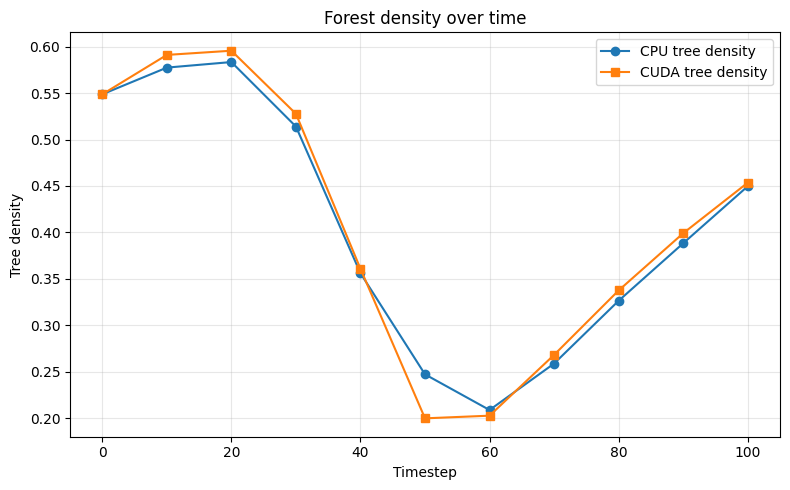

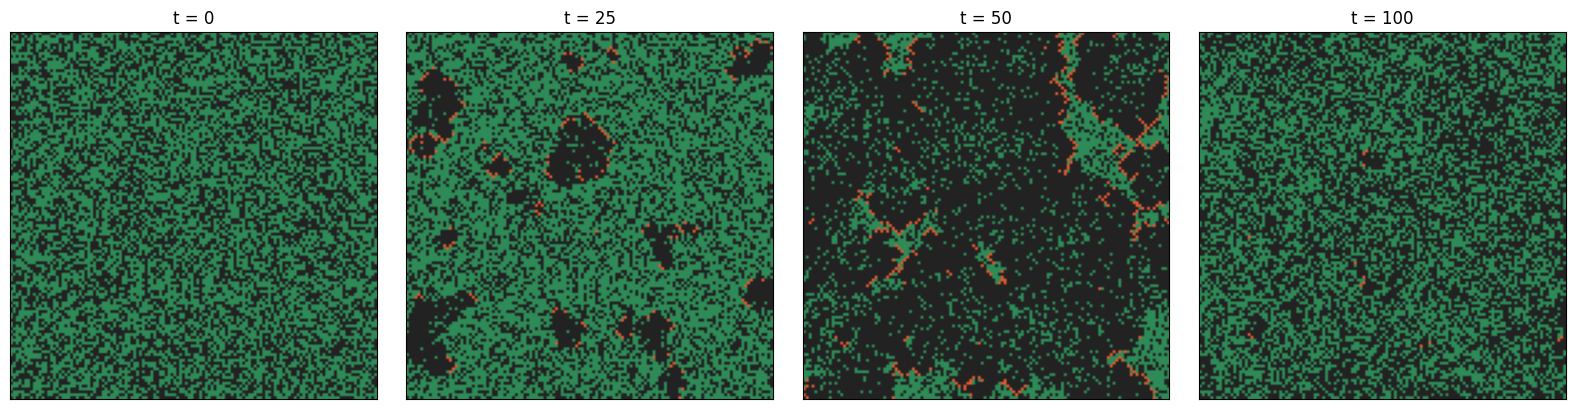

In [6]:
plot_density(cpu_demo, cuda_demo)

snapshots_to_plot = cuda_demo['snapshots'] if cuda_demo is not None else cpu_demo['snapshots']
plot_snapshots(snapshots_to_plot)

## Benchmark

This cell measures CPU and CUDA runtimes for different grid sizes and saves `results/timings.csv`.

For a faster first run, use `[128, 256, 512]`. For final plots, use `[128, 256, 512, 1024]`.

In [13]:
def run_benchmark(grid_sizes=(128, 256, 512, 1024, 2048, 4096), steps=200, growth=0.01, strike=0.0001, density=0.55, seed=42, record_every=None):
    rows = []
    has_cuda = cuda_available()
    if record_every is None:
        record_every = steps + 1


    for L in grid_sizes:
        print(f'Benchmark L={L}, steps={steps}')

        cpu_result = simulate_cpu(
            L=L,
            steps=steps,
            growth=growth,
            strike=strike,
            density=density,
            seed=seed,
            record_every=record_every,
        )
        cpu_time = cpu_result['runtime']

        cuda_time = float('nan')
        speedup = float('nan')
        if has_cuda:
            cuda_result = simulate_cuda(
                L=L,
                steps=steps,
                growth=growth,
                strike=strike,
                density=density,
                seed=seed,
                record_every=record_every,
            )
            if cuda_result is not None:
                cuda_time = cuda_result['runtime']
                speedup = cpu_time / cuda_time if cuda_time > 0 else float('nan')

        rows.append({
            'L': L,
            'steps': steps,
            'cpu_time': cpu_time,
            'cuda_time': cuda_time,
            'speedup': speedup,
        })
        print(rows[-1])

    csv_path = save_timings(rows)
    print(f'Saved benchmark results to {csv_path}')
    return rows


benchmark_rows = run_benchmark(
    grid_sizes=(128, 256, 512, 1024, 2048, 4096),
    steps=200,
    growth=GROWTH,
    strike=STRIKE,
    density=DENSITY,
    seed=SEED,
)

Benchmark L=128, steps=200
{'L': 128, 'steps': 200, 'cpu_time': 0.06778056699999979, 'cuda_time': 0.01807316700001138, 'speedup': 3.75034253819251}
Benchmark L=256, steps=200
{'L': 256, 'steps': 200, 'cpu_time': 0.2814777009998579, 'cuda_time': 0.04829772099992624, 'speedup': 5.827970661395965}
Benchmark L=512, steps=200
{'L': 512, 'steps': 200, 'cpu_time': 0.7591290689999823, 'cuda_time': 0.014543765000098574, 'speedup': 52.19618640667235}
Benchmark L=1024, steps=200
{'L': 1024, 'steps': 200, 'cpu_time': 2.9134451269999317, 'cuda_time': 0.05668405400001575, 'speedup': 51.397966825010826}
Benchmark L=2048, steps=200
{'L': 2048, 'steps': 200, 'cpu_time': 13.510930549000022, 'cuda_time': 0.21832698399998662, 'speedup': 61.8839242931183}
Benchmark L=4096, steps=200
{'L': 4096, 'steps': 200, 'cpu_time': 56.70346051399997, 'cuda_time': 0.5186928939999689, 'speedup': 109.31991004681737}
Saved benchmark results to results/timings.csv


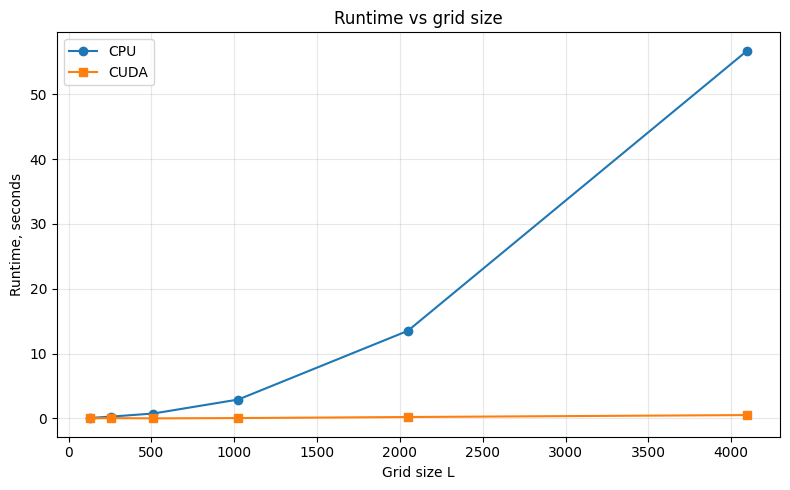

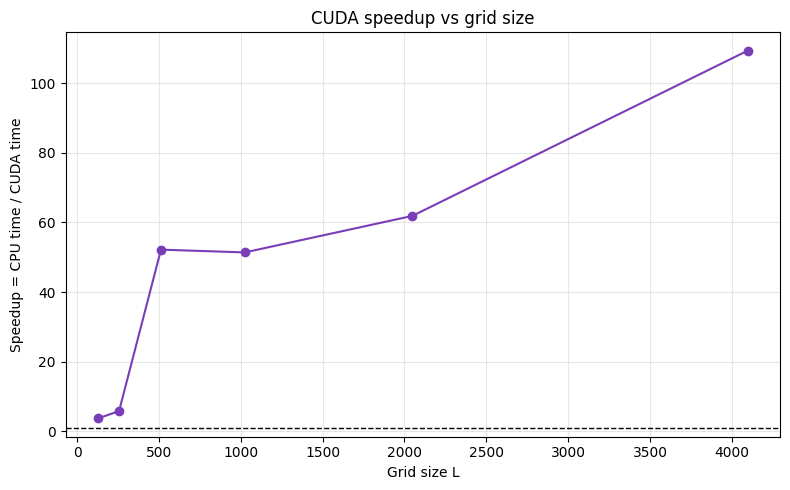

In [14]:
plot_runtime(benchmark_rows)
plot_speedup(benchmark_rows)

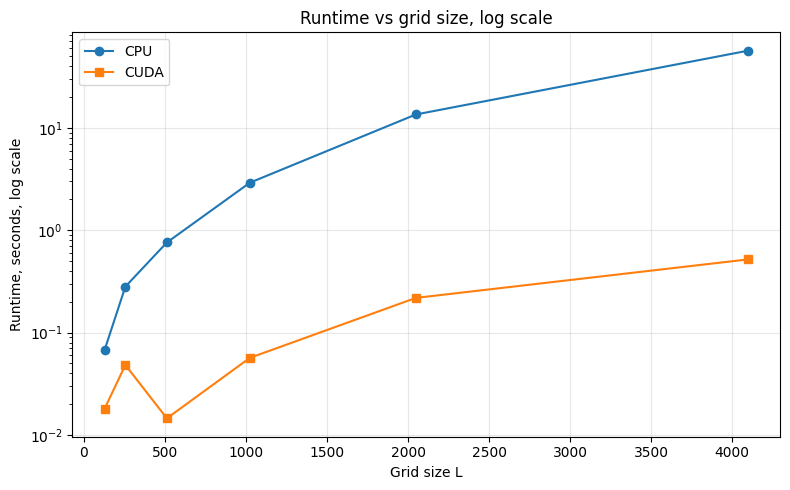

In [15]:
def plot_runtime_log(rows, output_path=RESULTS_DIR / 'runtime_log.png'):
    sizes = [row['L'] for row in rows]
    cpu_times = [row['cpu_time'] for row in rows]
    cuda_times = [row['cuda_time'] for row in rows]

    plt.figure(figsize=(8, 5))
    plt.plot(sizes, cpu_times, marker='o', label='CPU')
    plt.plot(sizes, cuda_times, marker='s', label='CUDA')
    plt.yscale('log')
    plt.xlabel('Grid size L')
    plt.ylabel('Runtime, seconds, log scale')
    plt.title('Runtime vs grid size, log scale')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()

plot_runtime_log(benchmark_rows)

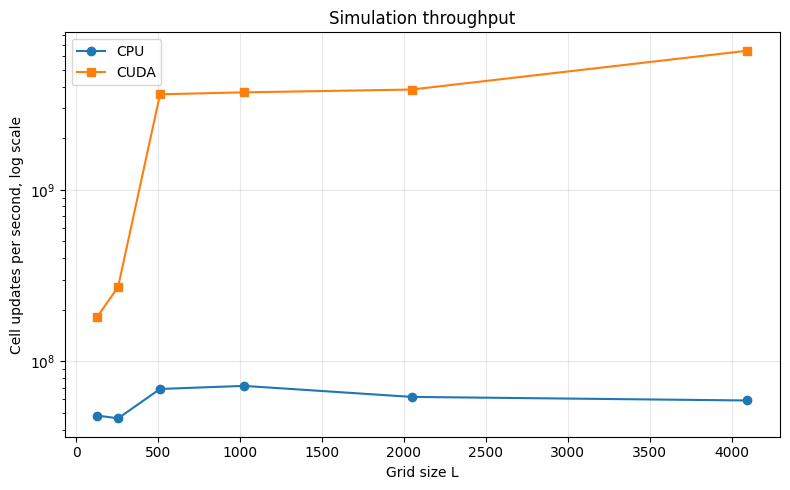

In [16]:
def plot_throughput(rows, output_path=RESULTS_DIR / 'throughput.png'):
    sizes = [row['L'] for row in rows]
    steps = [row['steps'] for row in rows]

    cpu_throughput = [
        (row['L'] ** 2 * row['steps']) / row['cpu_time']
        for row in rows
    ]

    cuda_throughput = [
        (row['L'] ** 2 * row['steps']) / row['cuda_time']
        for row in rows
        if not math.isnan(row['cuda_time'])
    ]

    cuda_sizes = [
        row['L']
        for row in rows
        if not math.isnan(row['cuda_time'])
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(sizes, cpu_throughput, marker='o', label='CPU')
    plt.plot(cuda_sizes, cuda_throughput, marker='s', label='CUDA')
    plt.yscale('log')
    plt.xlabel('Grid size L')
    plt.ylabel('Cell updates per second, log scale')
    plt.title('Simulation throughput')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()

plot_throughput(benchmark_rows)

In [17]:
for row in benchmark_rows:
    cells = row['L'] ** 2
    updates = cells * row['steps']
    cpu_tp = updates / row['cpu_time']
    cuda_tp = updates / row['cuda_time']

    print(
        f"L={row['L']}: "
        f"CPU={cpu_tp:,.0f} updates/s, "
        f"CUDA={cuda_tp:,.0f} updates/s"
    )

L=128: CPU=48,344,240 updates/s, CUDA=181,307,460 updates/s
L=256: CPU=46,565,678 updates/s, CUDA=271,383,405 updates/s
L=512: CPU=69,064,408 updates/s, CUDA=3,604,898,731 updates/s
L=1024: CPU=71,981,860 updates/s, CUDA=3,699,721,266 updates/s
L=2048: CPU=62,087,567 updates/s, CUDA=3,842,222,270 updates/s
L=4096: CPU=59,175,281 updates/s, CUDA=6,469,036,377 updates/s


In [18]:
def plot_snapshots_pretty(snapshots, output_path=RESULTS_DIR / 'snapshots_pretty.png'):
    if not snapshots:
        print('No snapshots to plot.')
        return

    steps = sorted(snapshots.keys())
    fig, axes = plt.subplots(1, len(steps), figsize=(4 * len(steps), 4))

    if len(steps) == 1:
        axes = [axes]

    for ax, step in zip(axes, steps):
        ax.imshow(snapshots[step], cmap=STATE_CMAP, norm=STATE_NORM)
        ax.set_title(f't = {step}', fontsize=14)
        ax.set_xticks([])
        ax.set_yticks([])

    # Custom legend
    legend_elements = [
        plt.Line2D([0], [0], marker='s', color='w', label='Empty',
                   markerfacecolor='#222222', markersize=12),
        plt.Line2D([0], [0], marker='s', color='w', label='Tree',
                   markerfacecolor='#2e8b57', markersize=12),
        plt.Line2D([0], [0], marker='s', color='w', label='Burning',
                   markerfacecolor='#e4572e', markersize=12),
    ]

    fig.legend(
        handles=legend_elements,
        loc='lower center',
        ncol=3,
        frameon=False,
        fontsize=12
    )

    fig.suptitle('Forest Fire Cellular Automaton Evolution', fontsize=16)
    plt.tight_layout(rect=[0, 0.12, 1, 0.92])
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()

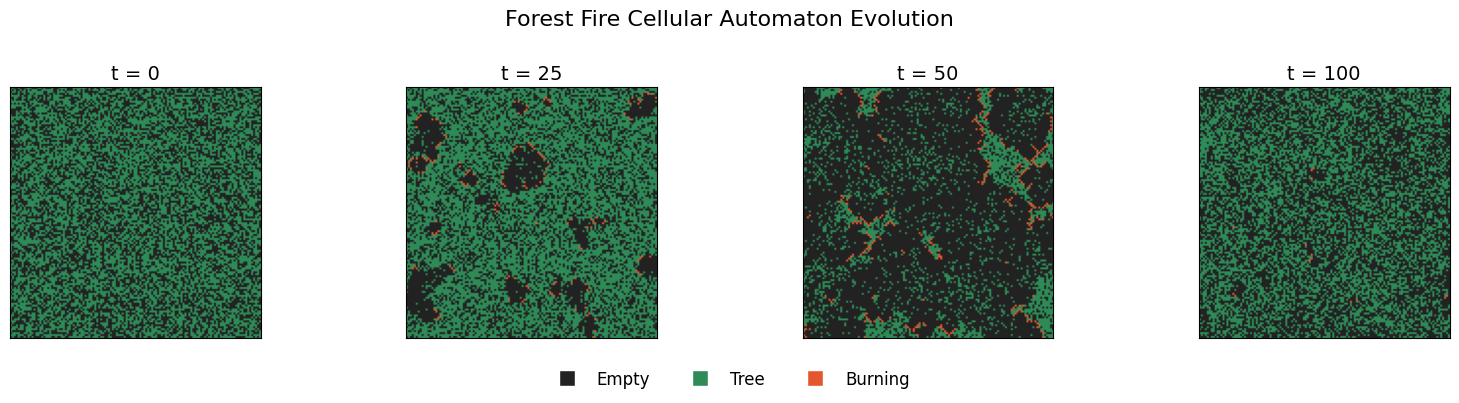

In [19]:
plot_snapshots_pretty(snapshots_to_plot)

## Benchmark Results

| Grid size `L` | Cells (`L × L`) | CPU time, s | CUDA time, s | Speedup |
|---:|---:|---:|---:|---:|
| 128  | 16,384      | 0.068 | 0.018 | **3.75×** |
| 256  | 65,536      | 0.281 | 0.048 | **5.83×** |
| 512  | 262,144     | 0.759 | 0.015 | **52.20×** |
| 1024 | 1,048,576   | 2.913 | 0.057 | **51.40×** |
| 2048 | 4,194,304   | 13.511 | 0.218 | **61.88×** |
| 4096 | 16,777,216  | 56.703 | 0.519 | **109.32×** |

## Results Discussion

The benchmark was performed for grid sizes from `128 × 128` to `4096 × 4096` using `200` timesteps. The results show that the CUDA implementation becomes significantly more efficient as the grid size increases.

For small grids, such as `128 × 128` and `256 × 256`, the speedup is limited because CUDA kernel launch overhead, memory transfers, and GPU under-utilization are relatively large compared to the amount of computation. This is why the speedup is only about **3.75×** and **5.83×** for these cases.

For larger grids, the GPU has much more parallel work to process. Starting from `512 × 512`, the CUDA implementation achieves more than **50×** speedup. The largest benchmark, `4096 × 4096`, contains more than **16 million cells** and reaches approximately **109×** speedup compared to the CPU baseline.

The runtime plot shows that CPU time grows rapidly with grid size, while CUDA time grows much more slowly. This confirms that the cellular automaton is well suited for GPU parallelization, because each cell can be updated based only on its local neighbour information.

## Additional Performance Analysis

Besides runtime and speedup, we also measured simulation throughput as the number of processed cell updates per second:

`throughput = L² × timesteps / runtime`

For the largest grid, `4096 × 4096`, the CPU baseline processed about **59 million cell updates per second**, while the CUDA implementation processed about **6.47 billion cell updates per second**. This shows that the GPU version is not only faster in total runtime, but also processes much more simulation work per second.

The main performance bottlenecks are:

- **CUDA overhead for small grids:** small grids do not provide enough parallel work to fully utilize the GPU.
- **Memory transfers:** copying data between CPU and GPU can reduce performance, so benchmark runs minimize host-device transfers.
- **Random number generation:** each cell needs pseudo-random values for growth and lightning events.
- **Branch divergence:** different cell states follow different branches inside the CUDA kernel.

## Conclusion

In this project, we implemented a 2D forest fire cellular automaton using both a vectorized NumPy CPU baseline and a CUDA GPU version. The CUDA implementation maps one GPU thread to one grid cell and uses synchronous updates with two grids: one grid for reading the old state and another grid for writing the next state.

The benchmark results demonstrate that CUDA provides a strong performance improvement for large simulations. The maximum observed speedup was approximately **109×** for the `4096 × 4096` grid. On this grid, CUDA processed about **6.47 billion cell updates per second**, compared to about **59 million updates per second** for the CPU baseline.

For smaller grids, the benefit is lower because CUDA overhead and GPU under-utilization dominate. Overall, the results show that forest fire cellular automata are a good fit for GPU acceleration, especially for large grid sizes and long simulations.